--- 1. GÉNÉRATION DES DONNÉES SIMULÉES ---
Dimensions du dataset original simulé : (1500, 8)

Distribution par niveau de risque d'audit :
risque_audit
Élevé     720
Modéré    509
Faible    271
Name: count, dtype: int64

--- 2. PRÉPARATION DES DONNÉES & FEATURE ENGINEERING ---
Classes détectées et encodées : [(0, 'Faible'), (1, 'Modéré'), (2, 'Élevé')]

--- 3. MODÉLISATION (5 Algorithmes de Classification) ---
Logistic Regression -> Accuracy: 0.8233
Random Forest -> Accuracy: 0.7767
SVM -> Accuracy: 0.7867
KNN -> Accuracy: 0.7067
XGBoost -> Accuracy: 0.7200

--- 4. ÉVALUATION DU MEILLEUR MODÈLE ---

Rapport de classification détaillé (XGBoost) :
              precision    recall  f1-score   support

      Faible       0.78      0.65      0.71        54
      Modéré       0.58      0.63      0.60       102
       Élevé       0.81      0.81      0.81       144

    accuracy                           0.72       300
   macro avg       0.72      0.70      0.71       300
weighted avg       0.

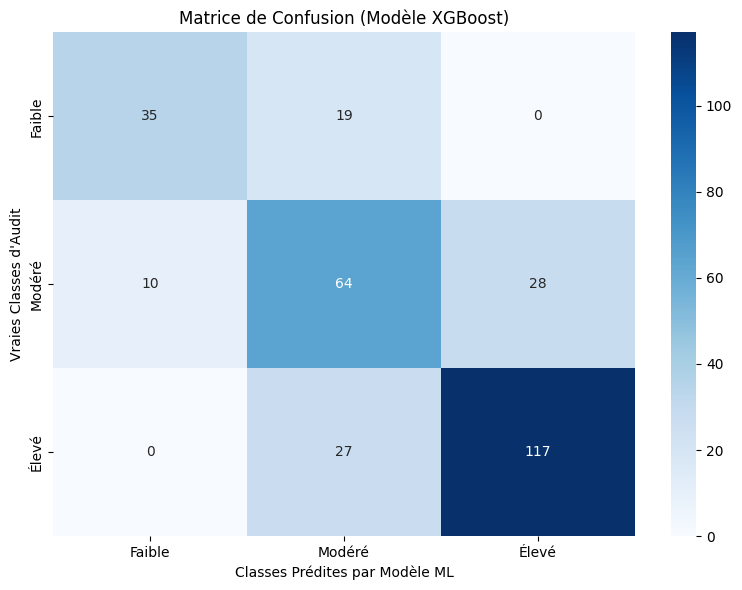

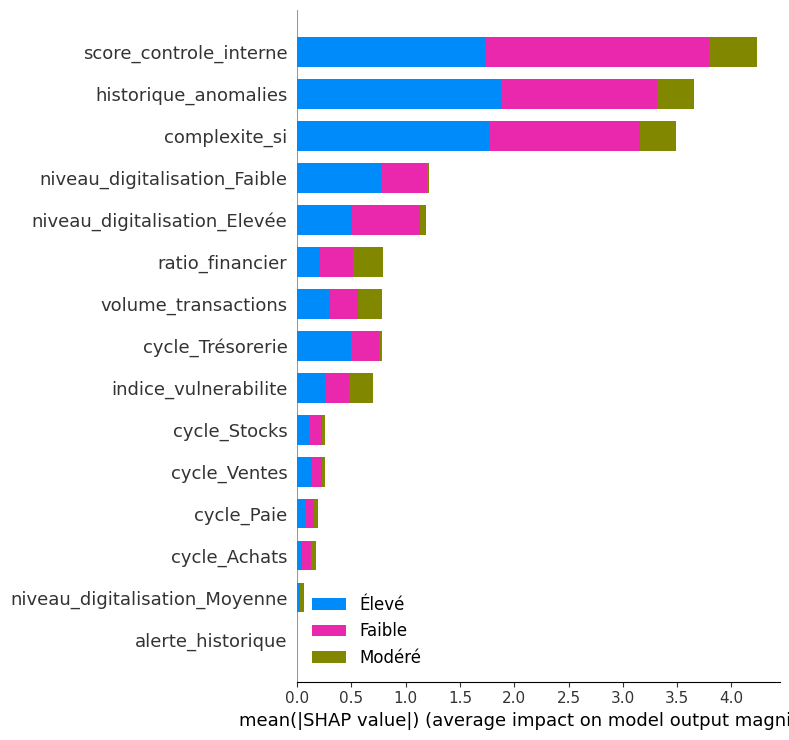

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import shap

def run_project():
    print("--- 1. GÉNÉRATION DES DONNÉES SIMULÉES ---")
    np.random.seed(42)
    n_samples = 1500

    cycles = ['Achats', 'Ventes', 'Paie', 'Trésorerie', 'Stocks']
    cycle_data = np.random.choice(cycles, n_samples)
    digitalisation_data = np.random.choice(['Faible', 'Moyenne', 'Elevée'], n_samples, p=[0.2, 0.5, 0.3])

    volume_transactions = np.abs(np.random.normal(50000, 20000, n_samples)).astype(int)
    complexite_si = np.random.randint(1, 6, n_samples)
    historique_anomalies = np.random.poisson(1.5, n_samples)
    ratio_financier = np.abs(np.random.normal(12, 5, n_samples))
    score_controle_interne = np.round(np.random.uniform(30, 100, n_samples), 2)

    df = pd.DataFrame({
        'cycle': cycle_data,
        'volume_transactions': volume_transactions,
        'complexite_si': complexite_si,
        'historique_anomalies': historique_anomalies,
        'ratio_financier': ratio_financier,
        'score_controle_interne': score_controle_interne,
        'niveau_digitalisation': digitalisation_data
    })

    # Variable Cible basée sur l'approche par les risques de l'audit
    risk_score = (
        df['historique_anomalies'] * 15 +
        df['complexite_si'] * 10 +
        (100 - df['score_controle_interne']) * 0.8 +
        np.random.normal(0, 10, n_samples)
    )

    risk_score = np.where(df['niveau_digitalisation'] == 'Faible', risk_score + 15, risk_score)
    risk_score = np.where(df['niveau_digitalisation'] == 'Elevée', risk_score - 10, risk_score)

    df['risk_score_temp'] = risk_score
    df.loc[df['cycle'] == 'Trésorerie', 'risk_score_temp'] += 15 # La trésorerie est naturellement très risquée
    df.loc[df['cycle'] == 'Achats', 'risk_score_temp'] += 5

    conditions = [
        (df['risk_score_temp'] < 55),
        (df['risk_score_temp'] >= 55) & (df['risk_score_temp'] < 85),
        (df['risk_score_temp'] >= 85)
    ]
    choices = ['Faible', 'Modéré', 'Élevé']
    df['risque_audit'] = np.select(conditions, choices, default='Modéré')
    df.drop('risk_score_temp', axis=1, inplace=True)

    print(f"Dimensions du dataset original simulé : {df.shape}")
    print("\nDistribution par niveau de risque d'audit :")
    print(df['risque_audit'].value_counts())

    print("\n--- 2. PRÉPARATION DES DONNÉES & FEATURE ENGINEERING ---")
    df['indice_vulnerabilite'] = df['volume_transactions'] / (df['score_controle_interne'] + 1)
    df['alerte_historique'] = (df['historique_anomalies'] > 2).astype(int)

    X = df.drop('risque_audit', axis=1)
    y = df['risque_audit']

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    classes_names = le.classes_
    print(f"Classes détectées et encodées : {list(zip(range(len(classes_names)), classes_names))}")

    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

    numeric_features = ['volume_transactions', 'complexite_si', 'historique_anomalies',
                        'ratio_financier', 'score_controle_interne', 'indice_vulnerabilite', 'alerte_historique']
    categorical_features = ['cycle', 'niveau_digitalisation']

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    print("\n--- 3. MODÉLISATION (5 Algorithmes de Classification) ---")
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial'),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'SVM': SVC(probability=True, random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    }

    results = {}
    for name, model in models.items():
        clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results[name] = {'Pipeline': clf, 'Accuracy': acc, 'Predictions': y_pred}
        print(f"{name} -> Accuracy: {acc:.4f}")

    print("\n--- 4. ÉVALUATION DU MEILLEUR MODÈLE ---")
    # Pour l'exemple final, on utilise XGBoost (souvent le plus performant ici)
    best_model_name = 'XGBoost'
    best_pipeline = results[best_model_name]['Pipeline']
    y_pred_best = results[best_model_name]['Predictions']

    print("\nRapport de classification détaillé (XGBoost) :")
    print(classification_report(y_test, y_pred_best, target_names=classes_names))

    # Génération et sauvegarde graphique de la matrice de confusion
    cm = confusion_matrix(y_test, y_pred_best)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
    plt.title('Matrice de Confusion (Modèle XGBoost)')
    plt.ylabel('Vraies Classes d\'Audit')
    plt.xlabel('Classes Prédites par Modèle ML')
    plt.tight_layout()
    plt.savefig('matrice_confusion_audit.png')
    print("✓ Matrice de confusion générée => 'matrice_confusion_audit.png'")

    print("\n--- 5. EXPLICABILITÉ (SHAP VALUES) ---")
    print("Génération de l'explicabilité du modèle : un élément indispensable pour valider l'approche auprès du CAC.")
    try:
        xgb_model = best_pipeline.named_steps['classifier']
        # Reconstruction des noms de features
        feature_names = numeric_features + list(best_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))

        # Transformation des données pour SHAP
        X_test_transformed = pd.DataFrame(best_pipeline.named_steps['preprocessor'].transform(X_test), columns=feature_names)
        explainer = shap.TreeExplainer(xgb_model)
        shap_values = explainer.shap_values(X_test_transformed)

        # Affichage et sauvegarde du graphique
        plt.figure()
        shap.summary_plot(shap_values, X_test_transformed, plot_type="bar", class_names=classes_names, show=False)
        plt.tight_layout()
        plt.savefig('shap_audit_explicabilite.png')
        print("✓ Graphique SHAP de l'importance des variables généré => 'shap_audit_explicabilite.png'")
    except Exception as e:
        print(f"Erreur lors de la génération avec SHAP : {e}\n(Assurez-vous que le module shap est installé via 'pip install shap')")

    print("\n--- PROCESSUS D'ANALYSE DATA SCIENCE RÉALISÉ AVEC SUCCÈS ---")

if __name__ == "__main__":
    run_project()
